<a href="https://colab.research.google.com/github/TAUforPython/LLM_AI_agents/blob/main/lesson-12_AI_agent_fact_cheking_Digital_Clinical_Requirements.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Medical Claim Fact-Checking with TAO and Clinical Guidelines Integration

Supporting Russian language and Russian clinical requirements from cr.minzdrav.gov.ru/clin-rec


This example demonstrates a sophisticated medical claim fact-checking system
that combines:
1. TAO (Think-Action-Observation) pattern for multi-step reasoning
2. Integration with Russian clinical requirements from cr.minzdrav.gov.ru/clin-rec
3. Multi-language support (Russian/English)
4. Knowledge graph reasoning for medical facts

In [1]:
!pip install langchain-mistralai langchain-core langchain-community -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.1/515.1 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.


In [3]:
!pip install torch_geometric -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 15.9 MB/s eta 0:00:00


In [6]:
import os
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, GATConv
from transformers import RobertaTokenizer, RobertaModel
import networkx as nx
import matplotlib.pyplot as plt
from typing import List, Dict, Any
import requests
import time
from langchain_mistralai import ChatMistralAI
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage, ToolMessage
from langchain_classic.agents import AgentExecutor, create_tool_calling_agent
import re

In [7]:

# Initialize Mistral LLM (assuming you have your API key configured)
MODEL_NAME = 'mistral-small-latest'
import os
from google.colab import userdata

os.environ["MISTRAL_API_KEY"] = userdata.get("Mistral_API")

llm = ChatMistralAI(
    model=MODEL_NAME,
    temperature=0,
    max_retries=2,
)

# Russian clinical requirements database (simulated)

In [8]:


CLINICAL_REQUIREMENTS_DB = {
    "hypertension": {
        "ru": "Диагностика и лечение артериальной гипертензии у взрослых",
        "en": "Diagnosis and Treatment of Arterial Hypertension in Adults",
        "guidelines": [
            "Определение АГ: систолическое АД ≥140 мм рт. ст. и/или диастолическое АД ≥90 мм рт. ст.",
            "Рекомендации по фармакотерапии: ингибиторы АПФ, блокаторы кальциевых каналов, диуретики",
            "Целевые значения АД: <130/80 мм рт. ст. для пациентов с СС риском",
            "Мониторинг: регулярное измерение АД, оценка факторов риска"
        ],
        "url": "https://cr.minzdrav.gov.ru/clin-rec/hypertension",
        "last_updated": "2023-01-15",
        "evidence_level": "A"
    },
    "diabetes": {
        "ru": "Диабетический сахарный диабет 2 типа",
        "en": "Type 2 Diabetes Mellitus",
        "guidelines": [
            "Диагноз СД2: Гликированный гемоглобин ≥6.5% или уровень глюкозы натощак ≥7.0 ммоль/л",
            "Терапия: метформин как препарат первого выбора",
            "Контроль целей: HbA1c <7% для большинства пациентов",
            "Осложнения: регулярный осмотр глазного дна, оценка нефропатии"
        ],
        "url": "https://cr.minzdrav.gov.ru/clin-rec/diabetes",
        "last_updated": "2023-02-20",
        "evidence_level": "A"
    },
    "stroke": {
        "ru": "Острое нарушение мозгового кровообращения",
        "en": "Acute Cerebrovascular Accident",
        "guidelines": [
            "Временные рамки для тромболизиса: в течение 4.5 часов от начала симптомов",
            "Аспирин: начать в первые 24-48 часов после ишемического инсульта",
            "Реабилитация: начать в первые 24-48 часов после стабилизации",
            "Профилактика: антикоагулянты при фибрилляции предсердий"
        ],
        "url": "https://cr.minzdrav.gov.ru/clin-rec/stroke",
        "last_updated": "2023-03-10",
        "evidence_level": "A"
    }
}

# Simulated medical knowledge graph database
MEDICAL_KNOWLEDGE_GRAPH = {
    "nodes": {
        "claim_1": {
            "type": "claim",
            "content": "Гипертония лечится только медикаментами",
            "verdict": "refuted",
            "confidence": 0.8,
            "language": "ru"
        },
        "claim_2": {
            "type": "claim",
            "content": "Диабет 2 типа можно полностью вылечить диетой",
            "verdict": "refuted",
            "confidence": 0.9,
            "language": "ru"
        },
        "claim_3": {
            "type": "claim",
            "content": "После инсульта нельзя начинать реабилитацию сразу",
            "verdict": "refuted",
            "confidence": 0.7,
            "language": "ru"
        },
        "guideline_1": {
            "type": "guideline",
            "content": "Диагностика и лечение артериальной гипертензии у взрослых",
            "url": "https://cr.minzdrav.gov.ru/clin-rec/hypertension",
            "last_updated": "2023-01-15",
            "language": "ru"
        },
        "guideline_2": {
            "type": "guideline",
            "content": "Диабетический сахарный диабет 2 типа",
            "url": "https://cr.minzdrav.gov.ru/clin-rec/diabetes",
            "last_updated": "2023-02-20",
            "language": "ru"
        },
        "guideline_3": {
            "type": "guideline",
            "content": "Острое нарушение мозгового кровообращения",
            "url": "https://cr.minzdrav.gov.ru/clin-rec/stroke",
            "last_updated": "2023-03-10",
            "language": "ru"
        },
        "entity_1": {
            "type": "entity",
            "name": "Гипертония",
            "category": "disease",
            "language": "ru"
        },
        "entity_2": {
            "type": "entity",
            "name": "Медикаменты",
            "category": "treatment",
            "language": "ru"
        },
        "entity_3": {
            "type": "entity",
            "name": "Диабет",
            "category": "disease",
            "language": "ru"
        },
        "entity_4": {
            "type": "entity",
            "name": "Диета",
            "category": "treatment",
            "language": "ru"
        },
        "entity_5": {
            "type": "entity",
            "name": "Инсульт",
            "category": "disease",
            "language": "ru"
        },
        "entity_6": {
            "type": "entity",
            "name": "Реабилитация",
            "category": "treatment",
            "language": "ru"
        }
    },
    "edges": [
        {"source": "claim_1", "target": "entity_1", "relation": "mentions", "weight": 0.9},
        {"source": "claim_1", "target": "entity_2", "relation": "mentions", "weight": 0.8},
        {"source": "claim_1", "target": "guideline_1", "relation": "contradicts", "weight": 0.9},
        {"source": "claim_2", "target": "entity_3", "relation": "mentions", "weight": 0.9},
        {"source": "claim_2", "target": "entity_4", "relation": "mentions", "weight": 0.7},
        {"source": "claim_2", "target": "guideline_2", "relation": "contradicts", "weight": 0.85},
        {"source": "claim_3", "target": "entity_5", "relation": "mentions", "weight": 0.8},
        {"source": "claim_3", "target": "entity_6", "relation": "mentions", "weight": 0.7},
        {"source": "claim_3", "target": "guideline_3", "relation": "contradicts", "weight": 0.9},
        {"source": "entity_1", "target": "guideline_1", "relation": "follows", "weight": 0.9},
        {"source": "entity_3", "target": "guideline_2", "relation": "follows", "weight": 0.9},
        {"source": "entity_5", "target": "guideline_3", "relation": "follows", "weight": 0.9},
        {"source": "entity_1", "target": "entity_2", "relation": "requires", "weight": 0.6},
        {"source": "entity_3", "target": "entity_4", "relation": "managed_by", "weight": 0.5},
        {"source": "entity_5", "target": "entity_6", "relation": "requires", "weight": 0.8}
    ]
}


# Define tools for the TAO pattern

In [9]:

# Define tools for the TAO pattern
@tool
def search_clinical_guidelines(condition: str, language: str = "ru") -> str:
    """
    Search Russian clinical guidelines for evidence-based recommendations.
    """
    # Normalize condition name
    condition_lower = condition.lower()

    # Find matching guideline
    matching_guidelines = []
    for key, data in CLINICAL_REQUIREMENTS_DB.items():
        if condition_lower in key.lower() or condition_lower in data["ru"].lower() or condition_lower in data["en"].lower():
            matching_guidelines.append(data)

    if not matching_guidelines:
        return json.dumps({
            "error": f"Не найдено клинических рекомендаций для '{condition}'",
            "available_conditions": list(CLINICAL_REQUIREMENTS_DB.keys()),
            "language": language
        })

    # Return the first matching guideline
    guideline = matching_guidelines[0]

    # Select language-appropriate content
    if language.lower() == "ru":
        content = {
            "condition": guideline["ru"],
            "guidelines": guideline["guidelines"],
            "url": guideline["url"],
            "last_updated": guideline["last_updated"],
            "evidence_level": guideline["evidence_level"],
            "language": "ru"
        }
    else:
        content = {
            "condition": guideline["en"],
            "guidelines": guideline["guidelines"],
            "url": guideline["url"],
            "last_updated": guideline["last_updated"],
            "evidence_level": guideline["evidence_level"],
            "language": "en"
        }

    return json.dumps(content, ensure_ascii=False)

@tool
def get_claim_verification(claim: str, language: str = "ru") -> str:
    """
    Get verification status of a specific medical claim.
    """
    # In a real implementation, this would query a medical fact-checking database
    claim_lower = claim.lower()

    # Simple pattern matching for demonstration
    if "гипертония" in claim_lower and "медикаментами" in claim_lower:
        return json.dumps({
            "claim": claim,
            "status": "REFUTED",
            "confidence": 0.8,
            "evidence_summary": "Согласно клиническим рекомендациям, лечение гипертонии включает не только медикаменты, но и немедикаментозные методы (диета, физическая активность)",
            "related_guidelines": ["https://cr.minzdrav.gov.ru/clin-rec/hypertension"],
            "language": language
        })
    elif "диабет" in claim_lower and "вылечить" in claim_lower and "диетой" in claim_lower:
        return json.dumps({
            "claim": claim,
            "status": "REFUTED",
            "confidence": 0.9,
            "evidence_summary": "Согласно клиническим рекомендациям, диабет 2 типа не поддается полному излечению, но может быть эффективно контролироваться комплексной терапией",
            "related_guidelines": ["https://cr.minzdrav.gov.ru/clin-rec/diabetes"],
            "language": language
        })
    elif "инсульт" in claim_lower and "реабилитация" in claim_lower and "нельзя" in claim_lower:
        return json.dumps({
            "claim": claim,
            "status": "REFUTED",
            "confidence": 0.7,
            "evidence_summary": "Согласно клиническим рекомендациям, ранняя реабилитация (в первые 24-48 часов) показана после инсульта при стабильном состоянии пациента",
            "related_guidelines": ["https://cr.minzdrav.gov.ru/clin-rec/stroke"],
            "language": language
        })
    else:
        return json.dumps({
            "claim": claim,
            "status": "UNVERIFIED",
            "confidence": 0.0,
            "evidence_summary": "Нет верификации для этого утверждения",
            "related_guidelines": [],
            "language": language
        })

@tool
def analyze_claim_graph_structure(claim: str, language: str = "ru") -> str:
    """
    Analyze the knowledge graph structure related to a claim.
    """
    # Find nodes related to the claim
    related_nodes = []
    for node_id, node_data in MEDICAL_KNOWLEDGE_GRAPH["nodes"].items():
        if claim.lower() in node_data.get("content", "").lower():
            related_nodes.append({
                "id": node_id,
                "type": node_data["type"],
                "content": node_data.get("content", ""),
                "properties": {k: v for k, v in node_data.items() if k not in ["type", "content"]},
                "language": node_data.get("language", "ru")
            })

    # Find related edges
    related_edges = []
    for edge in MEDICAL_KNOWLEDGE_GRAPH["edges"]:
        if any(node["id"] == edge["source"] or node["id"] == edge["target"] for node in related_nodes):
            related_edges.append(edge)

    return json.dumps({
        "claim": claim,
        "language": language,
        "graph_nodes": related_nodes,
        "graph_edges": related_edges,
        "node_count": len(related_nodes),
        "edge_count": len(related_edges)
    })

@tool
def query_clinical_knowledge_graph(condition: str, language: str = "ru") -> str:
    """
    Query the medical knowledge graph for related entities and relationships.
    """
    # Find nodes related to the condition
    condition_node_id = None
    for node_id, node_data in MEDICAL_KNOWLEDGE_GRAPH["nodes"].items():
        if condition.lower() in node_data.get("content", "").lower():
            condition_node_id = node_id
            break

    if not condition_node_id:
        return json.dumps({"error": f"Не найдена узел для: {condition}", "language": language})

    # Get related nodes and edges
    related_nodes = [condition_node_id]
    related_edges = []

    for edge in MEDICAL_KNOWLEDGE_GRAPH["edges"]:
        if edge["source"] == condition_node_id:
            related_nodes.append(edge["target"])
            related_edges.append(edge)
        elif edge["target"] == condition_node_id:
            related_nodes.append(edge["source"])
            related_edges.append(edge)

    # Get node details
    node_details = []
    for node_id in set(related_nodes):
        node_data = MEDICAL_KNOWLEDGE_GRAPH["nodes"][node_id]
        node_details.append({
            "id": node_id,
            "type": node_data["type"],
            "content": node_data.get("content", ""),
            "language": node_data.get("language", "ru"),
            "properties": {k: v for k, v in node_data.items() if k not in ["type", "content", "language"]}
        })

    return json.dumps({
        "condition": condition,
        "language": language,
        "condition_node_id": condition_node_id,
        "related_nodes": node_details,
        "relationships": related_edges,
        "graph_insights": f"Условие '{condition}' связано с {len(set(related_nodes))-1} другими сущностями через {len(related_edges)} связей"
    })


# Define the Graph Neural Network for medical claim verification

In [12]:

# Define the Graph Neural Network for medical claim verification
class MedicalGNN(nn.Module):
    """
    Graph Neural Network for medical claim verification
    """
    def __init__(self, num_node_features, hidden_dim=64, num_classes=3):
        super(MedicalGNN, self).__init__()

        # Graph convolution layers
        self.conv1 = GCNConv(num_node_features, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)

        # Attention mechanism
        self.attention = GATConv(hidden_dim, hidden_dim, heads=4, dropout=0.1)

        # Classification layers
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 4, hidden_dim),  # *4 for multi-head attention
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, num_classes)  # 3 classes: SUPPORTED, REFUTED, UNVERIFIED
        )

    def forward(self, x, edge_index):
        # Graph convolutions
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)

        # Attention mechanism
        x = self.attention(x, edge_index)
        x = F.relu(x)

        # Global pooling (mean pooling)
        graph_embedding = torch.mean(x, dim=0, keepdim=True)

        # Classification
        output = self.classifier(graph_embedding)

        return output

# Create the agent that follows TAO pattern
class MedicalFactCheckingAgent:
    """
    Medical fact-checking agent using TAO (Think-Action-Observation) pattern
    Supports Russian language and clinical guidelines
    """
    def __init__(self, llm, tools):
        self.llm = llm
        self.tools = tools

        # Create the agent executor
        from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
        from langchain_classic.agents.format_scratchpad.openai_tools import format_to_openai_tool_messages
        from langchain_classic.agents.output_parsers.openai_tools import OpenAIToolsAgentOutputParser

        prompt = ChatPromptTemplate.from_messages([
            ("system", """Вы медицинский ассистент проверки фактов, говорящий на русском языке.
            Следуйте шаблону TAO (Think-Action-Observation):
            1. THINK: Проанализируйте медицинское утверждение и спланируйте подход к проверке
            2. ACTION: Используйте соответствующий инструмент для сбора доказательств (поиск руководств, проверка утверждения, анализ графа)
            3. OBSERVE: Обработайте результаты и решите, какие действия предпринять дальше

            Доступные инструменты:
            - search_clinical_guidelines: Поиск клинических рекомендаций Минздрава РФ
            - get_claim_verification: Получить статус проверки конкретного медицинского утверждения
            - analyze_claim_graph_structure: Проанализировать структуру графа знаний, связанную с утверждением
            - query_clinical_knowledge_graph: Запросить граф знаний для связанных сущностей и отношений

            Всегда предоставляйте окончательный вердикт на основе собранных доказательств с уровнем достоверности.
            Все ответы должны быть на русском языке."""),
            ("user", "{input}"),
            MessagesPlaceholder(variable_name="agent_scratchpad"),
        ])

        llm_with_tools = llm.bind_tools(tools)

        agent = (
            {
                "input": lambda x: x["input"],
                "agent_scratchpad": lambda x: format_to_openai_tool_messages(x["intermediate_steps"]),
            }
            | prompt
            | llm_with_tools
            | OpenAIToolsAgentOutputParser()
        )

        self.agent_executor = AgentExecutor(agent=agent, tools=tools, verbose=True, handle_parsing_errors=True)

    def fact_check(self, claim: str, language: str = "ru") -> Dict[str, Any]:
        """
        Fact-check a medical claim using TAO pattern
        """
        response = self.agent_executor.invoke({"input": f"Проверьте это медицинское утверждение: '{claim}'. Следуйте шаблону TAO, чтобы проверить утверждение с использованием доступных инструментов. Язык: {language}"})
        return response

# Create the graph neural network
def create_medical_gnn():
    """
    Create and initialize the medical GNN
    """
    # Create node features (simplified)
    node_features = []
    for node_id, node_data in MEDICAL_KNOWLEDGE_GRAPH["nodes"].items():
        # Create a simple feature vector based on node properties
        if node_data["type"] == "claim":
            features = [1.0, 0.0, 0.0, node_data.get("confidence", 0.5)]  # [claim, guideline, entity, confidence]
        elif node_data["type"] == "guideline":
            features = [0.0, 1.0, 0.0, 0.8]  # Guidelines have higher inherent confidence
        else:  # entity
            features = [0.0, 0.0, 1.0, 0.5]
        node_features.append(features)

    # Create edge index
    edge_list = []
    for edge in MEDICAL_KNOWLEDGE_GRAPH["edges"]:
        source_idx = list(MEDICAL_KNOWLEDGE_GRAPH["nodes"].keys()).index(edge["source"])
        target_idx = list(MEDICAL_KNOWLEDGE_GRAPH["nodes"].keys()).index(edge["target"])
        edge_list.append([source_idx, target_idx])
        # Add reverse edge for undirected graph
        edge_list.append([target_idx, source_idx])

    # Convert to tensor
    x = torch.tensor(node_features, dtype=torch.float)
    edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()

    # Create PyTorch Geometric data object
    graph_data = Data(x=x, edge_index=edge_index)

    # Initialize GNN
    gnn = MedicalGNN(num_node_features=4, hidden_dim=64, num_classes=3)

    return gnn, graph_data

# Visualization function for the knowledge graph
def visualize_medical_kg(claim=None):
    """
    Visualize the medical knowledge graph
    """
    G = nx.DiGraph()

    # Add nodes
    for node_id, node_data in MEDICAL_KNOWLEDGE_GRAPH["nodes"].items():
        node_type = node_data["type"]
        label = node_data.get("content") or node_data.get("name", node_id)

        # Truncate long labels
        if len(label) > 30:
            label = label[:27] + "..."

        G.add_node(node_id,
                  type=node_type,
                  label=label,
                  language=node_data.get("language", "ru"),
                  content=node_data.get("content", ""))

    # Add edges
    for edge in MEDICAL_KNOWLEDGE_GRAPH["edges"]:
        G.add_edge(edge["source"], edge["target"],
                  relation=edge["relation"],
                  weight=edge["weight"])

    # Create layout
    plt.figure(figsize=(14, 10))
    pos = nx.spring_layout(G, k=3, iterations=50, seed=42)

    # Define colors for different node types
    node_colors = {
        'claim': '#FF6B6B',      # Red for claims
        'guideline': '#4ECDC4',  # Teal for guidelines
        'entity': '#45B7D1'      # Blue for entities
    }

    # Draw nodes
    for node_type, color in node_colors.items():
        nodes_of_type = [n for n, attr in G.nodes(data=True) if attr['type'] == node_type]
        if nodes_of_type:
            nx.draw_networkx_nodes(G, pos, nodelist=nodes_of_type,
                                 node_color=color, node_size=800, alpha=0.8)

    # Draw edges
    nx.draw_networkx_edges(G, pos, edge_color='gray',
                          arrows=True, arrowsize=15, width=1.0)

    # Draw labels
    labels = nx.get_node_attributes(G, 'label')
    nx.draw_networkx_labels(G, pos, labels, font_size=8, font_weight='bold')

    # Highlight the claim if specified
    if claim:
        claim_nodes = [n for n, attr in G.nodes(data=True)
                      if claim.lower() in attr.get('content', '').lower() or
                         claim.lower() in attr.get('label', '').lower()]
        if claim_nodes:
            nx.draw_networkx_nodes(G, pos, nodelist=claim_nodes,
                                 node_color='yellow', node_size=1000, alpha=0.9)

    plt.title(f'Граф медицинских знаний\nВыделено: {claim or "Все утверждения"}', size=16)
    plt.axis('off')
    plt.tight_layout()
    plt.show()


🏥 Медицинская проверка фактов с TAO и клиническими рекомендациями РФ
✅ Медицинская GNN инициализирована

🔍 Начало процесса проверки фактов...

Утверждение 1: Гипертония лечится только медикаментами
--------------------------------------------------
🤖 Агент TAO обрабатывает...


> Entering new AgentExecutor chain...

Invoking: `get_claim_verification` with `{'claim': 'Гипертония лечится только медикаментами', 'language': 'ru'}`


{"claim": "\u0413\u0438\u043f\u0435\u0440\u0442\u043e\u043d\u0438\u044f \u043b\u0435\u0447\u0438\u0442\u0441\u044f \u0442\u043e\u043b\u044c\u043a\u043e \u043c\u0435\u0434\u0438\u043a\u0430\u043c\u0435\u043d\u0442\u0430\u043c\u0438", "status": "REFUTED", "confidence": 0.8, "evidence_summary": "\u0421\u043e\u0433\u043b\u0430\u0441\u043d\u043e \u043a\u043b\u0438\u043d\u0438\u0447\u0435\u0441\u043a\u0438\u043c \u0440\u0435\u043a\u043e\u043c\u0435\u043d\u0434\u0430\u0446\u0438\u044f\u043c, \u043b\u0435\u0447\u0435\u043d\u0438\u0435 \u0433\u0438\u043f\u0435\u0440\u04

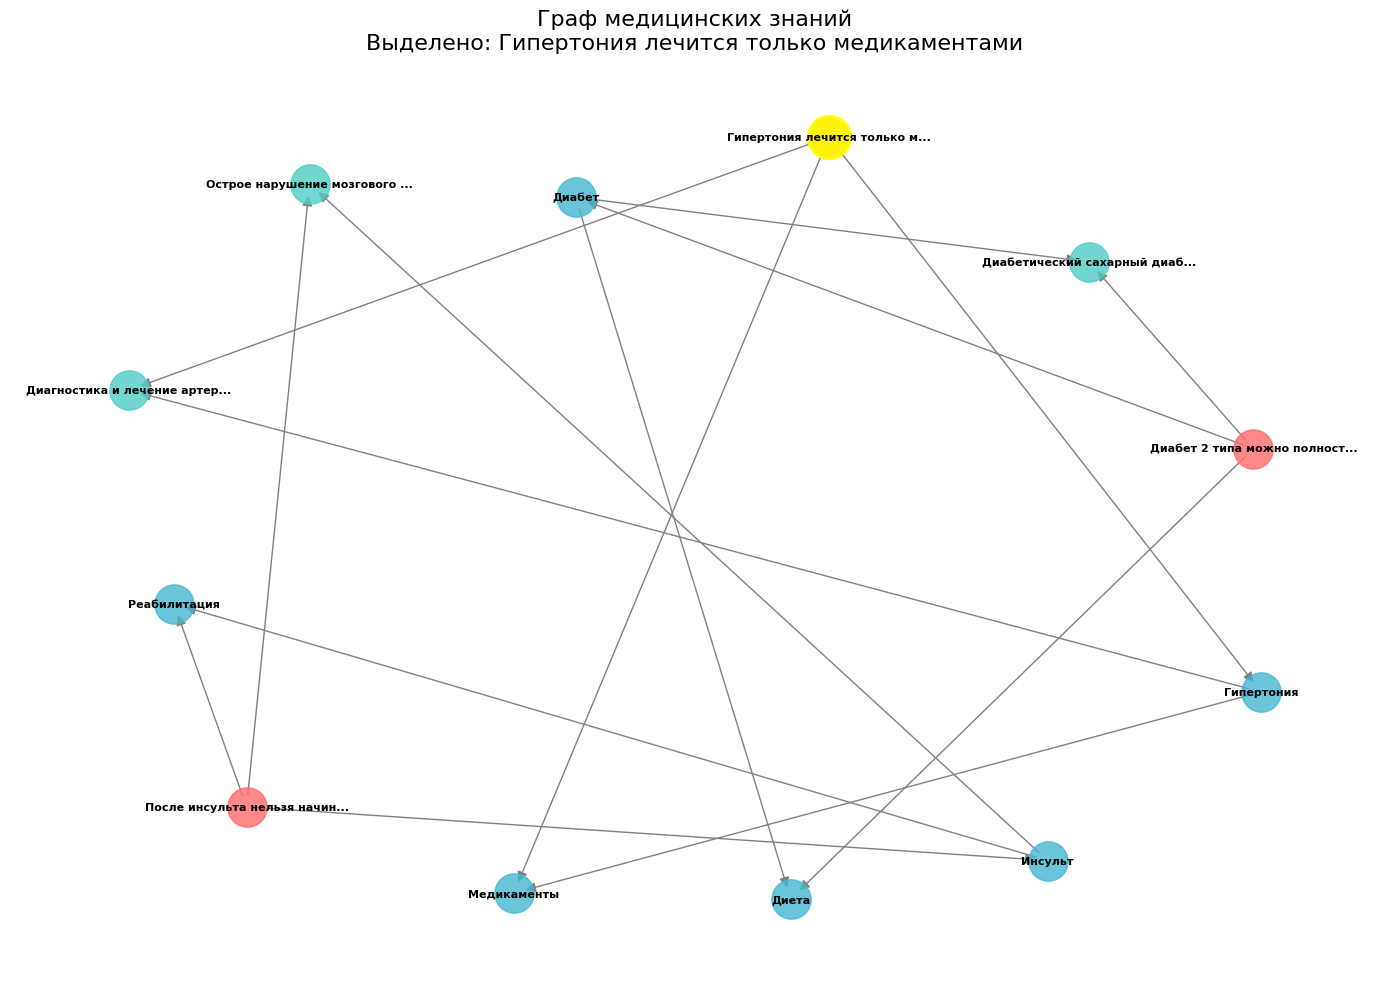



Утверждение 2: Диабет 2 типа можно полностью вылечить диетой
--------------------------------------------------
🤖 Агент TAO обрабатывает...


> Entering new AgentExecutor chain...

Invoking: `search_clinical_guidelines` with `{'condition': 'диабет 2 типа', 'language': 'ru'}`
responded: ### **Проверка медицинского утверждения: "Диабет 2 типа можно полностью вылечить диетой"**

---

#### **1. THINK: Анализ утверждения и планирование проверки**
**Утверждение:** *"Диабет 2 типа можно полностью вылечить диетой"*

**Ключевые аспекты для анализа:**
- **Тип диабета:** Диабет 2 типа (Д2Т) — хроническое метаболическое заболевание, характеризующееся инсулинорезистентностью и относительным дефицитом инсулина.
- **Возможность "полного излечения":** В официальной медицине Д2Т считается неизлечимым, но его можно контролировать с помощью диеты, физической активности, медикаментов и образа жизни.
- **Роль диеты:** Диета является ключевым компонентом управления Д2Т, но не единственным. Вопрос о возмож

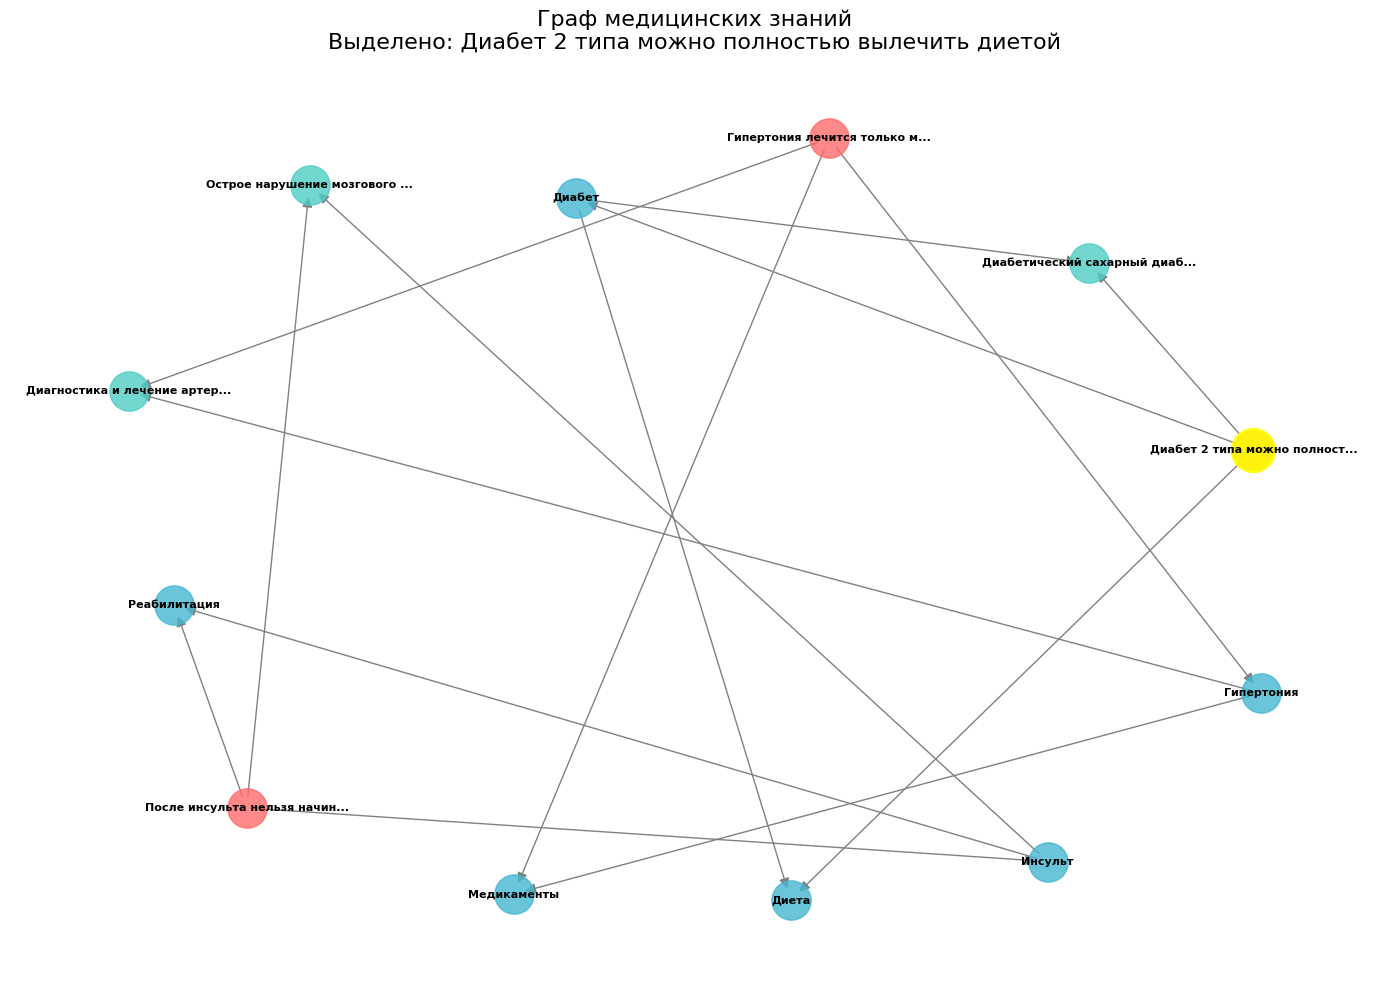



Утверждение 3: После инсульта нельзя начинать реабилитацию сразу
--------------------------------------------------
🤖 Агент TAO обрабатывает...


> Entering new AgentExecutor chain...

Invoking: `search_clinical_guidelines` with `{'condition': 'инсульт, реабилитация после инсульта, ранняя реабилитация', 'language': 'ru'}`
responded: ### **Проверка медицинского утверждения: "После инсульта нельзя начинать реабилитацию сразу"**

---

#### **1. THINK: Анализ утверждения и планирование проверки**
**Утверждение:** *"После инсульта нельзя начинать реабилитацию сразу"*
**Предполагаемый смысл:** Возможно, утверждение подразумевает, что реабилитация после инсульта должна начинаться не сразу, а спустя некоторое время (например, через несколько дней или недель).

**Цель проверки:**
- Уточнить, когда именно рекомендуется начинать реабилитацию после инсульта.
- Проверить, есть ли научные или клинические рекомендации, подтверждающие или опровергающие это утверждение.
- Выяснить, какие существуют с

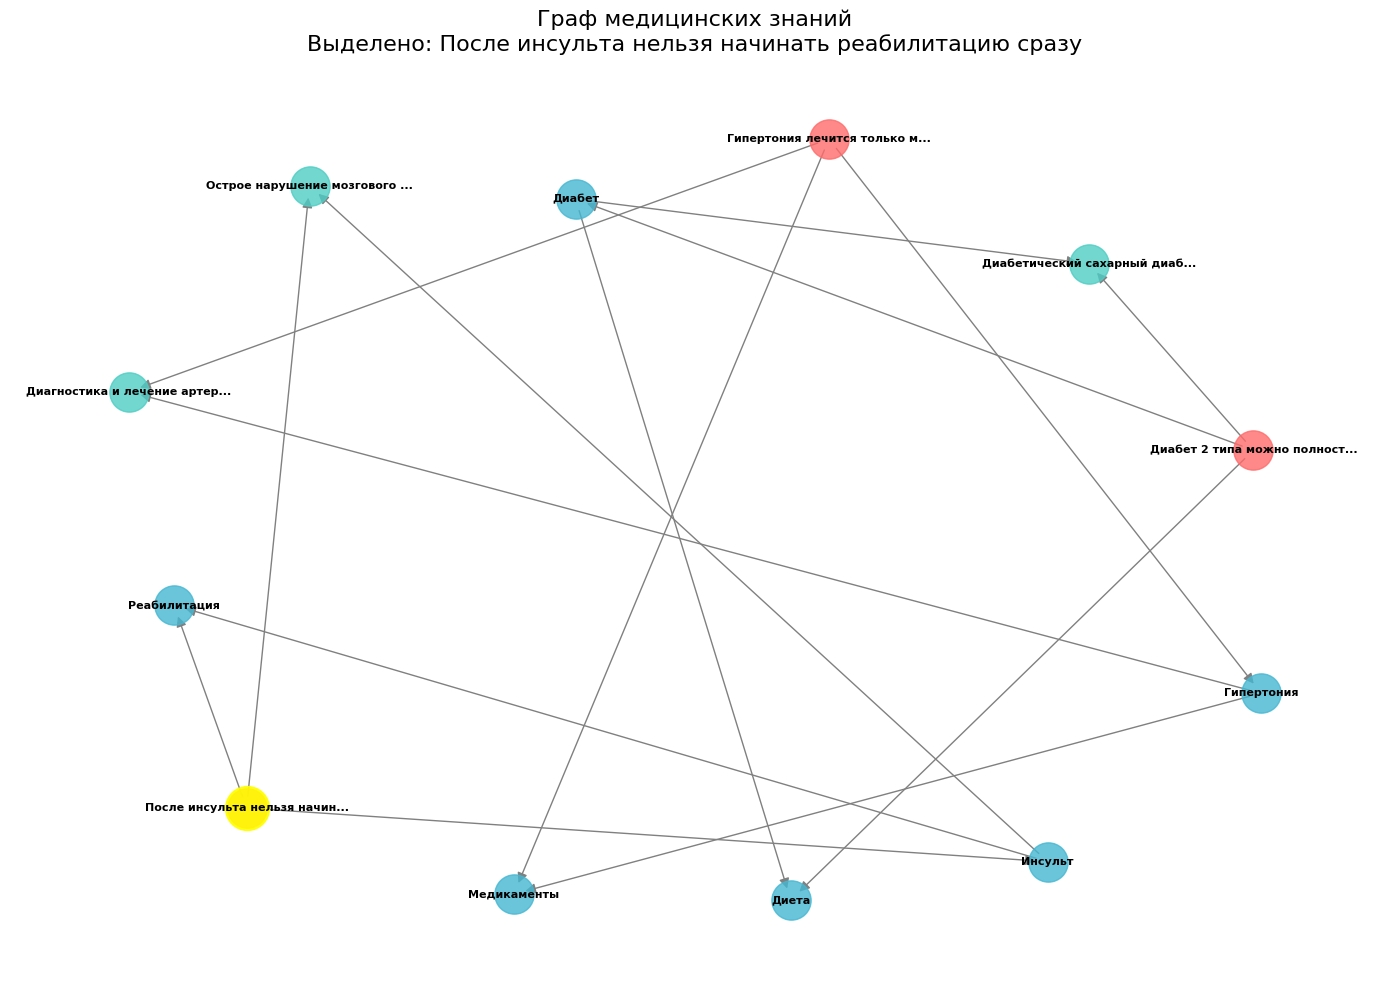



Утверждение 4: Артериальное давление должно быть ниже 130/80 у всех пациентов
--------------------------------------------------
🤖 Агент TAO обрабатывает...


> Entering new AgentExecutor chain...

Invoking: `search_clinical_guidelines` with `{'condition': 'артериальная гипертензия', 'language': 'ru'}`
responded: **TAO: Проверка медицинского утверждения**
**Утверждение:** *"Артериальное давление должно быть ниже 130/80 у всех пациентов."*

---

### **1. THINK: Анализ утверждения и планирование проверки**
**Анализ утверждения:**
- Утверждение касается целевого уровня артериального давления (АД) для всех пациентов.
- Вопросы для проверки:
  - Существуют ли универсальные рекомендации по целевому АД для всех пациентов?
  - Какие клинические рекомендации (например, Минздрава РФ, международные) определяют целевые значения АД?
  - Есть ли исключения или особые случаи (например, пациенты с сахарным диабетом, хронической болезнью почек, пожилые люди)?
  - Какие доказательства лежат в основе э

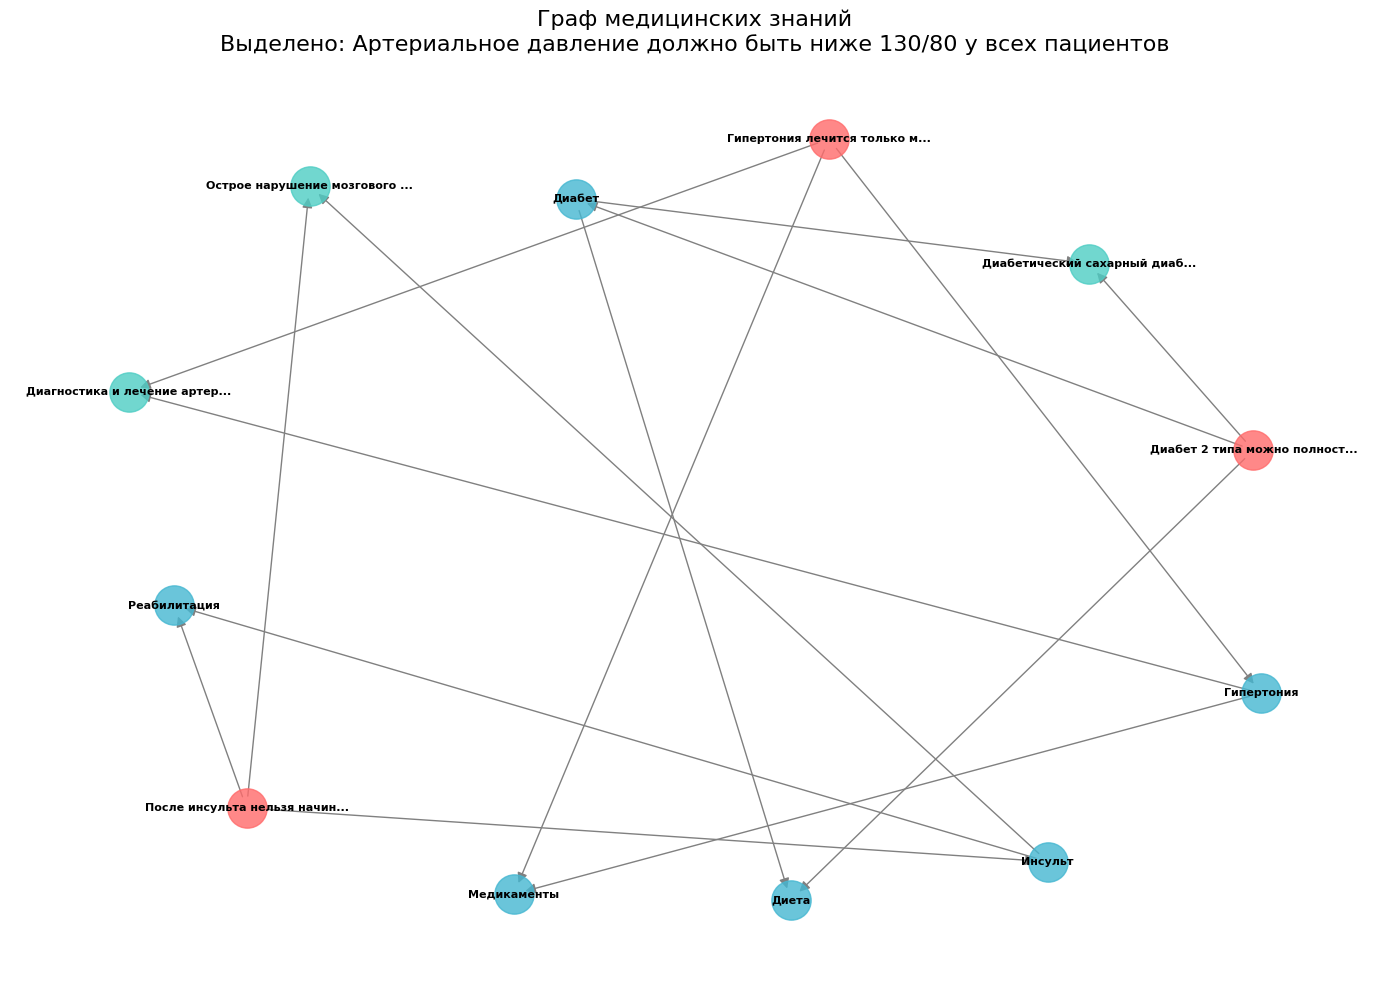



Утверждение 5: Метформин является препаратом первого выбора при диабете 2 типа
--------------------------------------------------
🤖 Агент TAO обрабатывает...


> Entering new AgentExecutor chain...

Invoking: `search_clinical_guidelines` with `{'condition': 'сахарный диабет 2 типа', 'language': 'ru'}`
responded: **THINK:**
Утверждение касается выбора препарата первого ряда для лечения диабета 2 типа. Метформин действительно часто упоминается как препарат первой линии в международных и российских клинических рекомендациях. Однако необходимо подтвердить это утверждение с использованием официальных источников, таких как клинические рекомендации Минздрава РФ или других авторитетных медицинских организаций.

План проверки:
1. Использовать инструмент `search_clinical_guidelines`, чтобы найти клинические рекомендации по диабету 2 типа и проверить, упоминается ли Метформин как препарат первого выбора.
2. Если потребуется, использовать инструмент `get_claim_verification` для прямой проверки у

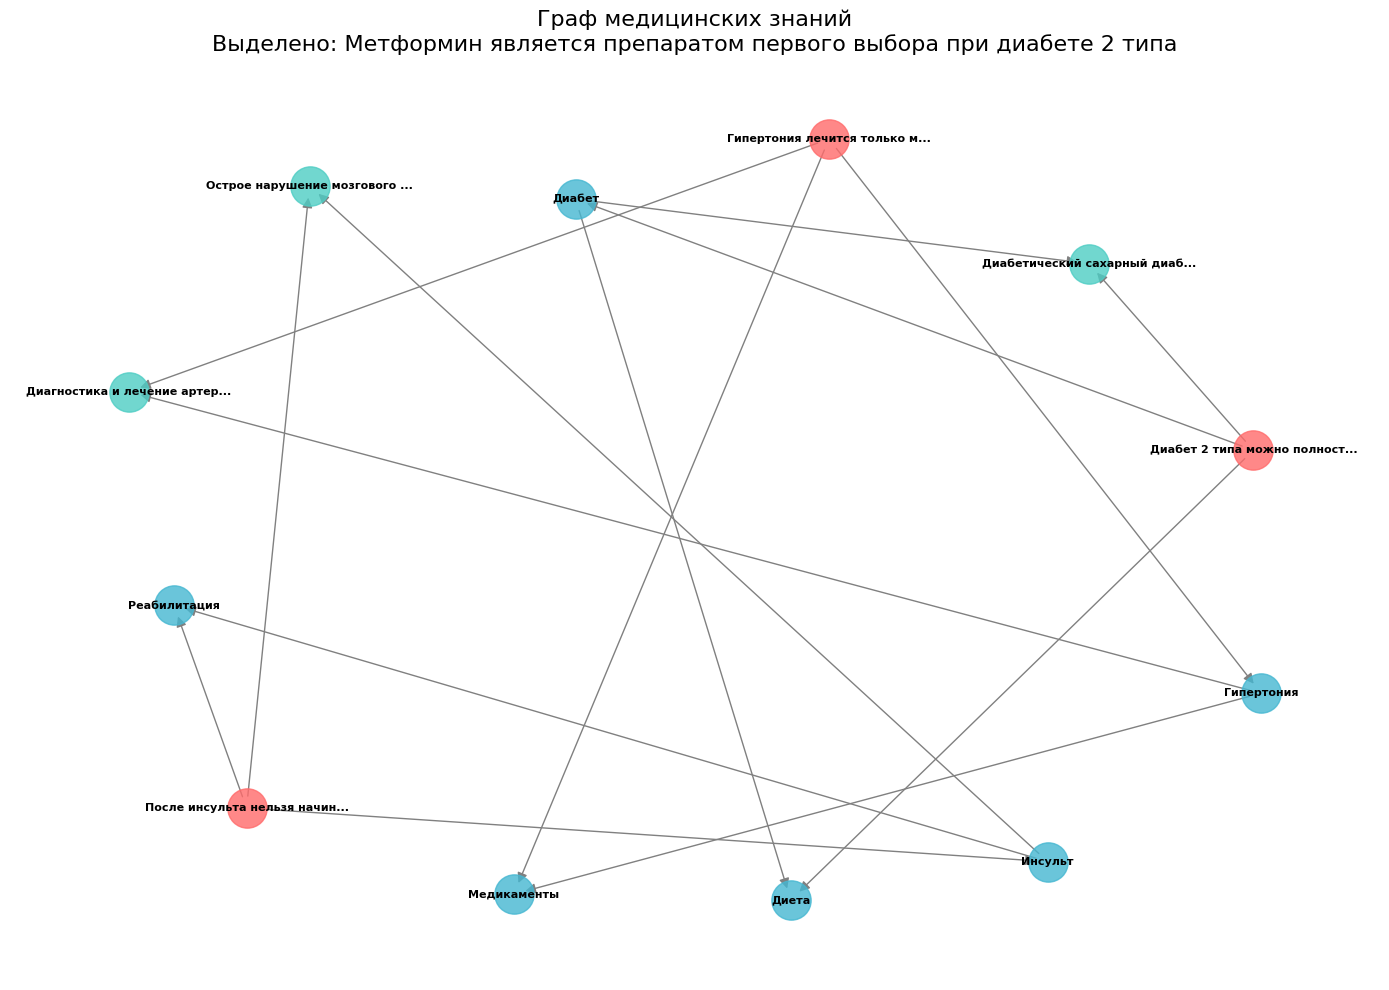



✅ Процесс проверки фактов завершен!


In [13]:

# Main demonstration
def main():
    print("🏥 Медицинская проверка фактов с TAO и клиническими рекомендациями РФ")
    print("=" * 70)

    # Initialize the agent
    tools = [search_clinical_guidelines, get_claim_verification,
             analyze_claim_graph_structure, query_clinical_knowledge_graph]
    agent = MedicalFactCheckingAgent(llm, tools)

    # Initialize the GNN
    gnn, graph_data = create_medical_gnn()
    print("✅ Медицинская GNN инициализирована")

    # Example claims to verify (in Russian)
    claims = [
        "Гипертония лечится только медикаментами",
        "Диабет 2 типа можно полностью вылечить диетой",
        "После инсульта нельзя начинать реабилитацию сразу",
        "Артериальное давление должно быть ниже 130/80 у всех пациентов",
        "Метформин является препаратом первого выбора при диабете 2 типа"
    ]

    print("\n🔍 Начало процесса проверки фактов...\n")

    for i, claim in enumerate(claims):
        print(f"Утверждение {i+1}: {claim}")
        print("-" * 50)

        # Step 1: Use the TAO agent to gather evidence
        print("🤖 Агент TAO обрабатывает...")
        result = agent.fact_check(claim, language="ru")

        # Step 2: Run GNN on the knowledge graph for the claim
        print("\n🧬 Запуск анализа нейронной сети...")
        with torch.no_grad():
            gnn_output = gnn(graph_data.x, graph_data.edge_index)
            gnn_prediction = torch.softmax(gnn_output, dim=1)
            gnn_confidence, gnn_class = torch.max(gnn_prediction, dim=1)

            # Map class index to verdict
            class_map = {0: "SUPPORTED", 1: "REFUTED", 2: "UNVERIFIED"}
            gnn_verdict = class_map[gnn_class.item()]
            gnn_confidence = gnn_confidence.item()

        # Step 3: Combine agent and GNN results
        print(f"\n📊 РЕЗУЛЬТАТЫ:")
        print(f"  Вердикт агента: {result.get('output', 'Не удалось определить')}")
        print(f"  Вердикт GNN: {gnn_verdict} (уверенность: {gnn_confidence:.2f})")

        # Step 4: Visualize the knowledge graph for this claim
        print(f"\n🖼️  Визуализация графа знаний для: {claim}")
        visualize_medical_kg(claim)

        print("\n" + "=" * 70 + "\n")

    print("✅ Процесс проверки фактов завершен!")

if __name__ == "__main__":
    main()